# XGBoost AQI Forecasting
### Same preprocessing as CNN-BiLSTM model for fair comparison

In [1]:
# ============================================================
# STEP 1: Install & Imports
# ============================================================
!pip install xgboost scikit-learn pandas numpy joblib -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('✅ Setup done!')

Mounted at /content/drive
✅ Setup done!


In [2]:
# ============================================================
# STEP 2: CONFIG
# ============================================================
DATA_PATH  = '/content/drive/MyDrive/INDIA_AQI_CLEANED.csv'
MODELS_DIR = '/content/drive/MyDrive/AQI_XGB_Models'
SEQ_LEN    = 48  # Same as LSTM

FEATURES = [
    'US_AQI', 'PM2_5_ugm3', 'PM10_ugm3', 'Temp_2m_C', 'Humidity_Percent',
    'Wind_Speed_10m_kmh', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2', 'Rain_mm',
]

os.makedirs(MODELS_DIR, exist_ok=True)
print('✅ Config done!')

✅ Config done!


In [3]:
# ============================================================
# STEP 3: Same Feature Engineering as LSTM
# ============================================================
def add_features(df):
    df = df.copy()
    df['hour_sin']  = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.month / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['Datetime'].dt.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['Datetime'].dt.dayofweek / 7)
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df[f'AQI_lag{lag}'] = df['US_AQI'].shift(lag)
    for window in [3, 6, 12, 24, 48]:
        df[f'AQI_roll{window}_mean'] = df['US_AQI'].rolling(window, min_periods=1).mean()
        df[f'AQI_roll{window}_std']  = df['US_AQI'].rolling(window, min_periods=1).std().fillna(0)
        df[f'AQI_roll{window}_max']  = df['US_AQI'].rolling(window, min_periods=1).max()
    for diff in [1, 3, 6, 24]:
        df[f'AQI_diff{diff}'] = df['US_AQI'].diff(diff).fillna(0)
    df['PM_ratio']        = (df['PM2_5_ugm3'] / (df['PM10_ugm3'] + 1e-6)).clip(0, 5)
    df['Heat_index']      = df['Temp_2m_C'] * df['Humidity_Percent'] / 100
    df['Wind_dilution']   = df['US_AQI'] / (df['Wind_Speed_10m_kmh'] + 1e-6)
    df['is_morning_rush'] = df['Datetime'].dt.hour.between(7, 10).astype(int)
    df['is_evening_rush'] = df['Datetime'].dt.hour.between(17, 20).astype(int)
    df['is_night']        = df['Datetime'].dt.hour.between(22, 5).astype(int)
    df['is_weekend']      = (df['Datetime'].dt.dayofweek >= 5).astype(int)
    return df

# XGBoost ke liye flat features banate hain (no sequences needed)
def prepare_flat_data(city_df):
    eng_cols = [
        'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos',
        'AQI_lag1','AQI_lag2','AQI_lag3','AQI_lag6','AQI_lag12','AQI_lag24','AQI_lag48',
        'AQI_roll3_mean','AQI_roll6_mean','AQI_roll12_mean','AQI_roll24_mean','AQI_roll48_mean',
        'AQI_roll3_std','AQI_roll6_std','AQI_roll24_std',
        'AQI_roll3_max','AQI_roll6_max','AQI_roll24_max',
        'AQI_diff1','AQI_diff3','AQI_diff6','AQI_diff24',
        'PM_ratio','Heat_index','Wind_dilution',
        'is_morning_rush','is_evening_rush','is_night','is_weekend',
    ]
    all_feats = FEATURES + [c for c in eng_cols if c in city_df.columns]
    data = city_df[all_feats].ffill().bfill().fillna(0)

    # Target: next hour AQI
    X = data.iloc[SEQ_LEN:-1].values
    y = data['US_AQI'].iloc[SEQ_LEN+1:].values
    return X, y, all_feats

print('✅ Functions ready!')

✅ Functions ready!


In [4]:
# ============================================================
# STEP 4: Train XGBoost for Each City
# ============================================================
def train_city_xgb(city_df, city):
    print(f"\n{'='*50}")
    print(f"  Training XGBoost: {city}  ({len(city_df)} rows)")
    print(f"{'='*50}")

    city_df = city_df.sort_values('Datetime').reset_index(drop=True)
    for col in FEATURES:
        if col in city_df.columns:
            city_df[col] = city_df[col].ffill().bfill().fillna(city_df[col].mean())

    city_df = add_features(city_df)

    X, y, feat_names = prepare_flat_data(city_df)

    if len(X) < 300:
        print(f'  ⚠️ Not enough data — skipping.')
        return None

    # Train/Val/Test split — same ratio as LSTM (80/10/10)
    n     = len(X)
    t_end = int(n * 0.80)
    v_end = int(n * 0.90)
    X_tr, y_tr = X[:t_end],      y[:t_end]
    X_v,  y_v  = X[t_end:v_end], y[t_end:v_end]
    X_te, y_te = X[v_end:],      y[v_end:]
    print(f'  Shapes → Train:{len(X_tr)} Val:{len(X_v)} Test:{len(X_te)}')

    model = xgb.XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = 42,
        n_jobs           = -1,
        early_stopping_rounds = 20,
        eval_metric      = 'mae',
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        verbose=50
    )

    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f'\n  ✅ RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')

    # Save model
    safe_name = city.replace(' ', '_')
    joblib.dump(model, os.path.join(MODELS_DIR, f'{safe_name}_xgb.pkl'))
    print(f'  💾 Saved!')

    return {'city': city, 'rmse': rmse, 'mae': mae, 'r2': r2}

print('✅ Train function ready!')

✅ Train function ready!


In [5]:
# ============================================================
# STEP 5: Run Training — Sab Cities
# ============================================================
print('\n📂 Loading dataset...')
df = pd.read_csv(DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.dropna(subset=['US_AQI'])

cities = sorted(df['City'].unique())
print(f'✅ Found {len(cities)} cities: {cities}')

results, failed = [], []
for city in cities:
    try:
        r = train_city_xgb(df[df['City'] == city].copy(), city)
        if r: results.append(r)
    except Exception as e:
        print(f'❌ FAILED {city}: {e}')
        failed.append(city)

print('\n' + '='*50)
print('🎉 XGBoost Training Complete!')
if results:
    res_df = pd.DataFrame(results).sort_values('r2', ascending=False)
    print('\n📊 XGBoost Model Performance:')
    print(res_df.to_string(index=False))
if failed:
    print(f'\n❌ Failed cities: {failed}')
print('='*50)


📂 Loading dataset...
✅ Found 29 cities: ['Agartala', 'Ahmedabad', 'Aizawl', 'Bengaluru', 'Bhopal', 'Bhubaneswar', 'Chandigarh', 'Chennai', 'Dehradun', 'Delhi', 'Gangtok', 'Gurugram', 'Guwahati', 'Hyderabad', 'Imphal', 'Itanagar', 'Jaipur', 'Kohima', 'Kolkata', 'Lucknow', 'Mumbai', 'Panaji', 'Patna', 'Raipur', 'Ranchi', 'Shillong', 'Shimla', 'Thiruvananthapuram', 'Visakhapatnam']

  Training XGBoost: Agartala  (29035 rows)
  Shapes → Train:23188 Val:2899 Test:2899
[0]	validation_0-mae:42.07448
[50]	validation_0-mae:3.78598
[100]	validation_0-mae:1.18951
[145]	validation_0-mae:1.14835

  ✅ RMSE=1.84  MAE=0.87  R²=0.9980
  💾 Saved!

  Training XGBoost: Ahmedabad  (29035 rows)
  Shapes → Train:23188 Val:2899 Test:2899
[0]	validation_0-mae:23.12955
[50]	validation_0-mae:2.42065
[100]	validation_0-mae:1.07747
[150]	validation_0-mae:1.02071
[200]	validation_0-mae:1.00958
[235]	validation_0-mae:1.00795

  ✅ RMSE=1.46  MAE=0.75  R²=0.9982
  💾 Saved!

  Training XGBoost: Aizawl  (29035 rows)
  

In [6]:
# ============================================================
# STEP 6: Comparison Table — LSTM vs XGBoost
# ============================================================
# LSTM results — paste karo apne LSTM training ke results yahan
lstm_results = [
    # {'city': 'Delhi',   'rmse': 12.5, 'mae': 8.3, 'r2': 0.92},
    # Apne LSTM results yahan add karo
]

if results and lstm_results:
    xgb_df  = pd.DataFrame(results).rename(columns={'rmse':'XGB_RMSE','mae':'XGB_MAE','r2':'XGB_R2'})
    lstm_df = pd.DataFrame(lstm_results).rename(columns={'rmse':'LSTM_RMSE','mae':'LSTM_MAE','r2':'LSTM_R2'})
    comp    = xgb_df.merge(lstm_df, on='city')
    comp['Better_Model'] = comp.apply(
        lambda r: 'LSTM' if r['LSTM_R2'] > r['XGB_R2'] else 'XGBoost', axis=1
    )
    print('\n📊 LSTM vs XGBoost Comparison:')
    print(comp.to_string(index=False))
    comp.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)
    print('\n💾 Comparison saved to Google Drive!')
else:
    print('XGBoost results:')
    print(pd.DataFrame(results).to_string(index=False))

XGBoost results:
              city      rmse      mae       r2
          Agartala  1.837841 0.870613 0.998009
         Ahmedabad  1.455245 0.754057 0.998201
            Aizawl  0.738486 0.546467 0.996486
         Bengaluru  0.864162 0.586667 0.999062
            Bhopal  0.921293 0.561387 0.999408
       Bhubaneswar  0.992227 0.628269 0.999436
        Chandigarh  2.815276 1.391994 0.989072
           Chennai  2.254607 1.076060 0.992952
          Dehradun  2.503531 1.236789 0.988246
             Delhi  9.906856 2.506163 0.980186
           Gangtok  1.006443 0.669067 0.996259
          Gurugram 27.634449 5.089064 0.971555
          Guwahati  0.866484 0.553153 0.996704
         Hyderabad  0.848264 0.578754 0.999411
            Imphal  0.639727 0.464487 0.997086
          Itanagar  0.731527 0.529962 0.996114
            Jaipur  1.828411 0.979921 0.996825
            Kohima  0.682240 0.508322 0.996280
           Kolkata  1.492888 0.807794 0.999197
           Lucknow  1.063330 0.660573 0.999

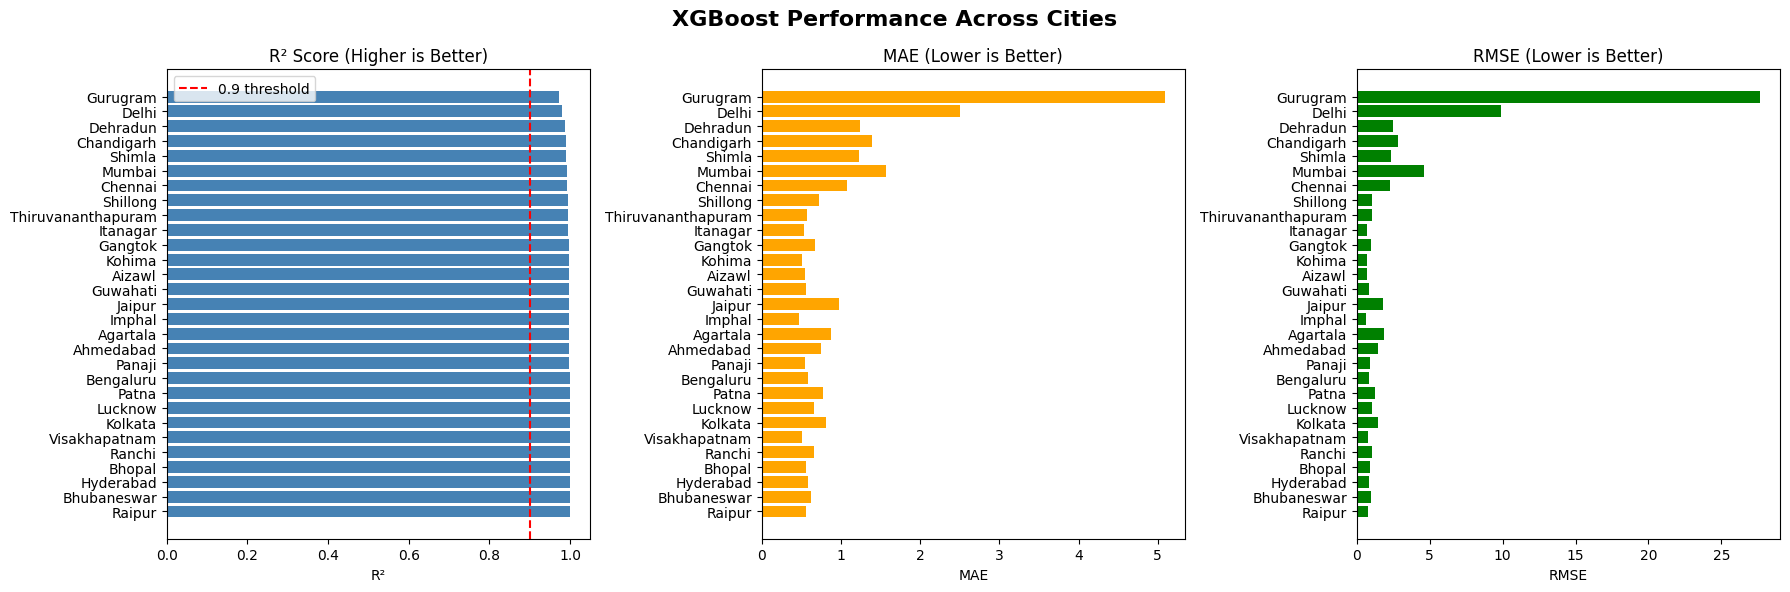

✅ Plot saved!


In [7]:
# ============================================================
# STEP 7: Visualization — LSTM vs XGBoost
# ============================================================
import matplotlib.pyplot as plt

if results:
    res_df = pd.DataFrame(results).sort_values('r2', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('XGBoost Performance Across Cities', fontsize=16, fontweight='bold')

    # R2 Score
    axes[0].barh(res_df['city'], res_df['r2'], color='steelblue')
    axes[0].set_title('R² Score (Higher is Better)')
    axes[0].set_xlabel('R²')
    axes[0].axvline(x=0.9, color='red', linestyle='--', label='0.9 threshold')
    axes[0].legend()

    # MAE
    axes[1].barh(res_df['city'], res_df['mae'], color='orange')
    axes[1].set_title('MAE (Lower is Better)')
    axes[1].set_xlabel('MAE')

    # RMSE
    axes[2].barh(res_df['city'], res_df['rmse'], color='green')
    axes[2].set_title('RMSE (Lower is Better)')
    axes[2].set_xlabel('RMSE')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/xgboost_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Plot saved!')

In [8]:
# ============================================================
# STEP 8: Download Models as ZIP
# ============================================================
import shutil
shutil.make_archive('/content/AQI_XGB_Models', 'zip',
                    '/content/drive/MyDrive/AQI_XGB_Models')
from google.colab import files
files.download('/content/AQI_XGB_Models.zip')
print('✅ XGBoost Models downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ XGBoost Models downloaded!
